In [1]:
import pandas as pd
import torch as pt
pt.set_default_dtype(pt.float64)
import numpy as np

import os
import dill

from cnmc import CNMc, ROMList
from cnmc.cnmc.utils_cnmc import (custom_dict_to_sparse_coo, 
                                  dict_to_sparse_coo,
                                  rearrange_tensor_sparse, 
                                  unify_sparse_tensors, 
                                  unified_sparse_to_dense_flat)

from cnmc.encoders.ProcrustesEncoder import ProcrustesEncoder


# reproducibility
pt.manual_seed(4224)
np.random.seed(4224)

# plot Settings
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True # fixes the minus sign


In [2]:
from cnmc_config_newcnmc import *

outpath=casepath+'K{:d}_L{:d}/'.format(K,L)
if daniel: path_daniel = base_path+f'Data/Rho-40-60_paolo/{K}Clusters/'

os.makedirs(outpath, exist_ok=True)

In [3]:
param_train = [PARAMETERS[i] for i in ids_train]
param_test = [PARAMETERS[i] for i in ids_test]

In [4]:
data=[]
test_data=[]
times=[]
for filename in FILENAMES:
    d = pd.read_csv(DATAPATH+filename, header=None, index_col=0)[[1,2,3,4]].to_numpy()
    dt = d[1,0]-d[0,0]
    print(dt)
    d = pt.from_numpy(d.T)
    print(d.shape)
    data.append(d[1:4, ti_train:tf_train])
    test_data.append(d[1:4, ti_test:tf_test])
    # data.append(d[1:4, :])

T = dt * data[0].shape[-1]

0.010000009999998838
torch.Size([4, 950000])
0.010000009999998838
torch.Size([4, 950000])
0.010000009999998838
torch.Size([4, 950000])
0.010000009999998838
torch.Size([4, 950000])
0.010000009999998838
torch.Size([4, 950000])


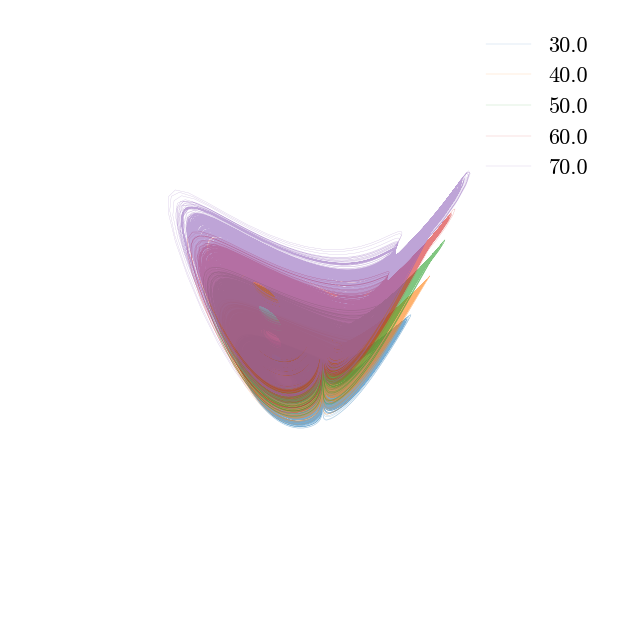

In [13]:
# Visualise data

# %matplotlib ipympl
%matplotlib inline

fig = plt.figure(figsize=(4,4), dpi=160)
ax = fig.add_subplot(1,1,1, projection='3d', proj_type='ortho',computed_zorder=False)
ax.view_init(15, 80)
# ax.view_init(14, 65)
# ax.view_init(12, 140)
for i, traj_data in enumerate(data):
    coarse = traj_data[:,:100_000:1]
    x = coarse[0,:]
    y = coarse[1,:]
    z = coarse[2,:]
    # ax.scatter(x, y, z, alpha=0.4, s=1, zorder=1, label=PARAMETERS[i])
    ax.plot(x, y, z, alpha=0.6, zorder=1, lw=0.1, label=PARAMETERS[i])
# plt.legend()
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_zlabel('$z$')
plt.legend(frameon=False)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(outpath+'datavis.png')
plt.show()

In [6]:
from sklearn.cluster import KMeans
from flowtorch.rom import CNM
from cnmc.cnmc.transformation_clustering import read_clusters_from_file
from cnmc.encoders.mean_std_model import procrustes_model

# training data
data_train = [data[id] for id in ids_train]

# set up clustering
cluster_config = {'n_clusters': K, 'n_init': n_init, 'max_iter': max_iter, 'init': 'k-means++'}
clustering = {'algorithm': KMeans(**cluster_config)}
clusters_csv = 'clusters.csv'
if not compute_clusters:
    # clusters_csv = casepath+'clusters/bigclusters_K'+str(K)+'.csv'
    clusters_from_file = read_clusters_from_file(clusters_csv, **cluster_config)
    clustering = {'algorithm': clusters_from_file}
    # print(clusters_from_file.cluster_centers_)

# set up and store CNM models into ROMList 
kwargs_cnm = {'dt': dt, 
              'encoder': None, 
              'n_clusters': K, 
              'model_order': L,
              'spline_order': spline_order,}
cnms = ROMList([{"oc": oc, "rom": CNM(**kwargs_cnm)} for oc in param_train])

# set up and initialise Procrustes encoders
encoders = [encoder_class(reference_state=data_train[0]) for oc in param_train]

# get and initialise CNMc
cnmc = CNMc(cnms, 
            encoders=encoders,
            clustering=clustering, 
            encoder_model=procrustes_model(),
            transition_model=transition_model
            )

# train CNMc
cnmc.train(data_train)

# writing out models
models_cnm = {param_test[0]: cnmc}
with open(outpath+'models_cnm.pkl', 'wb') as f:
    dill.dump(models_cnm, f)

/home/paolo/Desktop/semaan/semaan-project/cnm/hands-on/flowtorch/env_flotorch/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


Using precomputed clusters
Using precomputed clusters
nnz = 33
Using precomputed clusters
nnz = 33
Using precomputed clusters
nnz = 31
Using precomputed clusters
nnz = 34


In [7]:
# train the reference test CNM

from cnmc.cnmc.transformation_clustering import train_croms, train_clusters

data_test = [data[id] for id in ids_test]

cnms_test = ROMList([{"oc": oc, "rom": CNM(**kwargs_cnm)} for oc in param_test])
encoders_test = [encoder_class(reference_state=data_train[0]).train(data) for data in data_test]

cluster_config = {'n_clusters': K, 'n_init': n_init, 'max_iter': max_iter, 'init': 'k-means++'}
clusters_ocs_csv = 'clusters_test.csv'
if compute_ocs_clusters:
    clustering_test = {'algorithm': KMeans(**cluster_config)}
    data_test_encoded = [encoder.encode(data) for data, encoder in zip(data_test, encoders_test)]
    clustering_test = train_clusters(clustering_test, data_test_encoded, output_csv=clusters_ocs_csv)
    del data_test_encoded
else:
    # clusters_ocs_csv = casepath+'clusters/clusters_50.0_K14.csv'
    clusters_from_file = read_clusters_from_file(clusters_ocs_csv, **cluster_config)
    clustering_test = {'algorithm': clusters_from_file}

cnmlist_test = train_croms(cnms_test.roms, data_test, encoders_test, clustering_test, encode=True)

for i, _ in enumerate(cnmlist_test[:-1]):
    assert(np.all(cnmlist_test[i].cluster_centers==cnmlist_test[i+1].cluster_centers))

models_cnm_test = {param: trained_cnm for param, trained_cnm in zip(param_test, cnmlist_test)}
with open(outpath+'models_cnm_test.pkl', 'wb') as f:
    dill.dump(models_cnm_test, f)

Using precomputed clusters
nnz = 36


In [8]:
# Test Predictions
print('Predict at: ', param_test)

oc=pt.Tensor(param_test) # batch of 1 OCs
cnms_oc = cnmc.predict_model(oc)

Predict at:  [(50.0,)]


In [10]:
# Dynamics prediction

# CNM true trajectory.
true_traj = test_data[ids_test[0]]
print(dt)
print(true_traj.shape)

# initial state
x0 = pt.Tensor(true_traj[:,1_000]).unsqueeze(-1) #pt.Tensor(cnmlist_test[0].cluster_centers[3])

# CNM reference prediction
test_traj_cnm = cnmlist_test[0].predict(x0,T,dt)
print(cnmlist_test[0].encoder.scale_)
pd.DataFrame(test_traj_cnm.T).to_csv(outpath+'traj_cnm.csv', header=None)
print(test_traj_cnm.shape)

# CNMc prediction
test_traj_cnmc = cnms_oc[0].predict(x0,T,dt)
pd.DataFrame(test_traj_cnmc.T).to_csv(outpath+'traj_cnmc.csv', header=None)
print(test_traj_cnmc.shape)


0.010000009999998838
torch.Size([3, 400000])
tensor([21.1585])
torch.Size([3, 400003])
torch.Size([3, 400002])


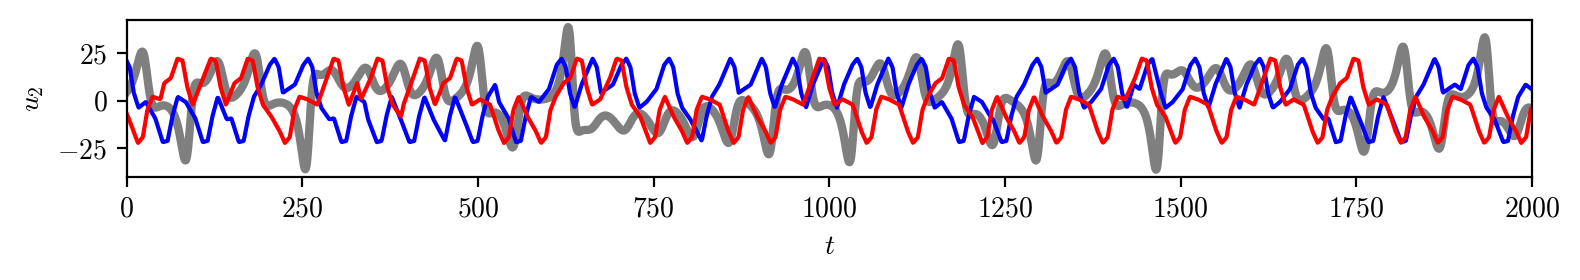

In [11]:
# Plot trajectory
xa, xb = 2000, 4000
plt.figure(figsize=(8,1.5), dpi=200)
plt.plot(true_traj[1,xa:xb], c='k', alpha=0.5, label='numerical', lw=3)
crd = 1
plt.plot(test_traj_cnm[crd,xa:xb], c='b', label='cnm')
if daniel: plt.plot(test_traj_daniel[crd,xa:xb], c='mediumseagreen', label='FSN21')
plt.plot(test_traj_cnmc[crd,xa:xb], c='r', label='cnmc')
# plt.legend(frameon=False,)
plt.xlim((0, xb-xa))
plt.xlabel('$t$')
plt.ylabel(f'$u_{crd+1}$')
# plt.title(r'{\sf\textbf{A}}', loc='left')
plt.tight_layout()
plt.savefig(outpath+'time_series.png')
plt.show()